In [1]:
!pip install -q librosa soundfile audiomentations scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 15.8 MB/s eta 0:00:00


In [2]:
import os
import glob
import random
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Librosa:", librosa.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-06-11 16:33:24.009639: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781195604.217047      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781195604.271133      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781195604.714478      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781195604.714521      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781195604.714524      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Librosa: 0.11.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# Inspect available dataset paths on Kaggle
for dirname, _, filenames in os.walk('/kaggle/input'):
    if len(filenames) > 0:
        print(dirname, '->', len(filenames), 'files (sample:', filenames[0], ')')

/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake -> 5398 files (sample: file7803.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav )
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/real -> 5400 files (sample: file30967.wav_16k.wav_norm.wav_mono.wav_silence.wav )
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training/fake -> 26927 files (sample: file14215.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav )
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training/real -> 26941 files (sample: file30736.wav_16k.wav_norm.wav_mono.wav_silence.wav )
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/testing/fake -> 2370 files (sample: file508.wav_16k.wav_norm.wav_mono.wav_silence.wav )
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/testing/real -> 2264 file

In [4]:
DATA_ROOT ="/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training"
REAL_DIR = os.path.join(DATA_ROOT, "real")
FAKE_DIR = os.path.join(DATA_ROOT, "fake")

real_files = glob.glob(os.path.join(REAL_DIR, "*.wav"))
fake_files = glob.glob(os.path.join(FAKE_DIR, "*.wav"))
print(f"Real samples: {len(real_files)}")
print(f"Fake samples: {len(fake_files)}")

# Debug: check what's actually there
print(os.listdir(REAL_DIR)[:5] if os.path.exists(REAL_DIR) else "REAL_DIR doesn't exist")
print(os.path.exists(os.path.join(DATA_ROOT, "training")))
print(os.listdir(os.path.join(DATA_ROOT, "training")) if os.path.exists(os.path.join(DATA_ROOT, "training")) else "no training")

Real samples: 26941
Fake samples: 26927
['file30736.wav_16k.wav_norm.wav_mono.wav_silence.wav', 'file25321.wav_16k.wav_norm.wav_mono.wav_silence.wav', 'file20017.wav_16k.wav_norm.wav_mono.wav_silence.wav', 'file31620.wav_16k.wav_norm.wav_mono.wav_silence.wav', 'file8127.wav_16k.wav_norm.wav_mono.wav_silence.wav']
False
no training


In [5]:
# Build a unified dataframe (subsample for faster experimentation if needed)
MAX_PER_CLASS = None  # set an int (e.g., 3000) to subsample for quick iteration

if MAX_PER_CLASS:
    random.shuffle(real_files)
    random.shuffle(fake_files)
    real_files = real_files[:MAX_PER_CLASS]
    fake_files = fake_files[:MAX_PER_CLASS]

df = pd.DataFrame({
    "filepath": real_files + fake_files,
    "label": [0] * len(real_files) + [1] * len(fake_files)  # 0 = Genuine, 1 = Deepfake
})

df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(df['label'].value_counts())
df.head()

label
0    26941
1    26927
Name: count, dtype: int64


,filepath,label
0,/kaggle/input/datasets/mohammedabdeldayem/the-...,0
1,/kaggle/input/datasets/mohammedabdeldayem/the-...,0
2,/kaggle/input/datasets/mohammedabdeldayem/the-...,0
3,/kaggle/input/datasets/mohammedabdeldayem/the-...,0
4,/kaggle/input/datasets/mohammedabdeldayem/the-...,0


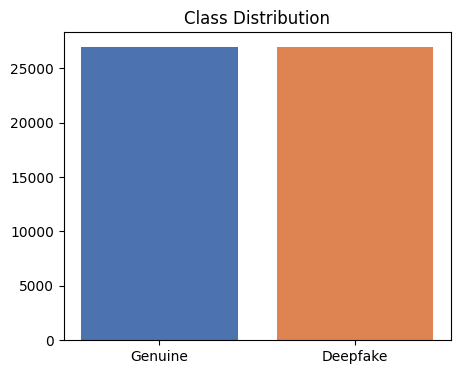

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['label'].map({0: "Genuine", 1: "Deepfake"}).value_counts()
ax.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
ax.set_title("Class Distribution")
plt.show()

In [7]:
SR = 16000  # target sample rate
DURATION = 4  # seconds, fixed clip length for model input
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512

def load_audio(path, sr=SR, duration=DURATION):
    """Load audio, resample, and pad/trim to a fixed duration."""
    y, _ = librosa.load(path, sr=sr, mono=True)
    target_len = sr * duration
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y

def audio_to_logmel(y, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Convert waveform to a log-mel spectrogram."""
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return log_mel

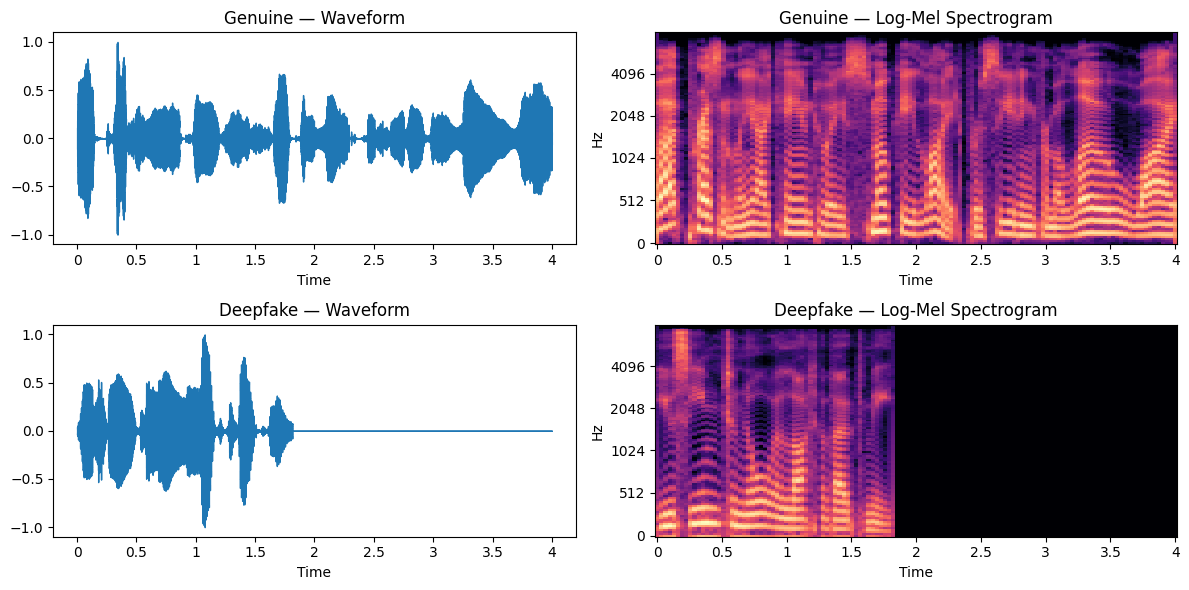

In [8]:
# Visualize one sample from each class
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for i, (label_val, label_name) in enumerate([(0, "Genuine"), (1, "Deepfake")]):
    sample_path = df[df.label == label_val].iloc[0]['filepath']
    y = load_audio(sample_path)
    log_mel = audio_to_logmel(y)

    librosa.display.waveshow(y, sr=SR, ax=axes[i, 0])
    axes[i, 0].set_title(f"{label_name} — Waveform")

    img = librosa.display.specshow(log_mel, sr=SR, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f"{label_name} — Log-Mel Spectrogram")

plt.tight_layout()
plt.show()

In [9]:
def extract_features(filepath):
    try:
        y = load_audio(filepath)
        log_mel = audio_to_logmel(y)
        return log_mel.astype(np.float32)
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return None

# Probe shape
sample_feat = extract_features(df.iloc[0]['filepath'])
print("Feature shape:", sample_feat.shape)
FEATURE_SHAPE = sample_feat.shape

Feature shape: (128, 126)


In [10]:
# Extract features for the full dataset (cached to .npy for reproducibility)
FEATURES_PATH = "features.npy"
LABELS_PATH = "labels.npy"

if os.path.exists(FEATURES_PATH) and os.path.exists(LABELS_PATH):
    X = np.load(FEATURES_PATH)
    y_all = np.load(LABELS_PATH)
else:
    X_list, y_list = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        feat = extract_features(row['filepath'])
        if feat is not None:
            X_list.append(feat)
            y_list.append(row['label'])

    X = np.stack(X_list)
    y_all = np.array(y_list)
    np.save(FEATURES_PATH, X)
    np.save(LABELS_PATH, y_all)

print("X shape:", X.shape, "| y shape:", y_all.shape)

  0%|          | 0/53868 [00:00<?, ?it/s]

X shape: (53868, 128, 126) | y shape: (53868,)


In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_all, test_size=0.30, stratify=y_all, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Normalize using train-set statistics
mean, std = X_train.mean(), X_train.std()
X_train_norm = (X_train - mean) / (std + 1e-9)
X_val_norm   = (X_val - mean) / (std + 1e-9)
X_test_norm  = (X_test - mean) / (std + 1e-9)

np.save("norm_stats.npy", np.array([mean, std]))

# Add channel dimension for CNN
X_train_cnn = X_train_norm[..., np.newaxis]
X_val_cnn   = X_val_norm[..., np.newaxis]
X_test_cnn  = X_test_norm[..., np.newaxis]

print("CNN input shape:", X_train_cnn.shape)

Train: (37707, 128, 126) Val: (8080, 128, 126) Test: (8081, 128, 126)
CNN input shape: (37707, 128, 126, 1)


In [12]:
def build_cnn(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_cnn(X_train_cnn.shape[1:])
model.summary()

I0000 00:00:1781196650.742804      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781196650.749636      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 31, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_all, test_size=0.30, stratify=y_all, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Normalize using train-set statistics
mean, std = X_train.mean(), X_train.std()
X_train_norm = (X_train - mean) / (std + 1e-9)
X_val_norm   = (X_val - mean) / (std + 1e-9)
X_test_norm  = (X_test - mean) / (std + 1e-9)

np.save("norm_stats.npy", np.array([mean, std]))

# Add channel dimension for CNN
X_train_cnn = X_train_norm[..., np.newaxis]
X_val_cnn   = X_val_norm[..., np.newaxis]
X_test_cnn  = X_test_norm[..., np.newaxis]

print("CNN input shape:", X_train_cnn.shape)

Train: (37707, 128, 126) Val: (8080, 128, 126) Test: (8081, 128, 126)
CNN input shape: (37707, 128, 126, 1)


In [17]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

early_stop = callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=8, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6
)
checkpoint = callbacks.ModelCheckpoint(
    "best_model.keras", monitor='val_auc', mode='max', save_best_only=True
)

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Class weights: {0: np.float64(0.9997613744829781), 1: np.float64(1.000238739455674)}
Epoch 1/40
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.9999 - auc: 1.0000 - loss: 2.6433e-04 - val_accuracy: 0.9994 - val_auc: 1.0000 - val_loss: 0.0017 - learning_rate: 1.2500e-04
Epoch 2/40
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 4.0801e-05 - val_accuracy: 0.9996 - val_auc: 1.0000 - val_loss: 7.9600e-04 - learning_rate: 1.2500e-04
Epoch 3/40
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 5.5491e-05 - val_accuracy: 0.9994 - val_auc: 0.9999 - val_loss: 0.0020 - learning_rate: 1.2500e-04
Epoch 4/40
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 5.8934e-05 - val_accuracy: 0.9999 - val_auc: 1.0000 - val_loss: 4.2627e-04 - learning_rate: 1.2500e-04
Epoch 5/40
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.9999 - auc: 1.0000 - loss: 1.2445e-04 - val_accuracy:

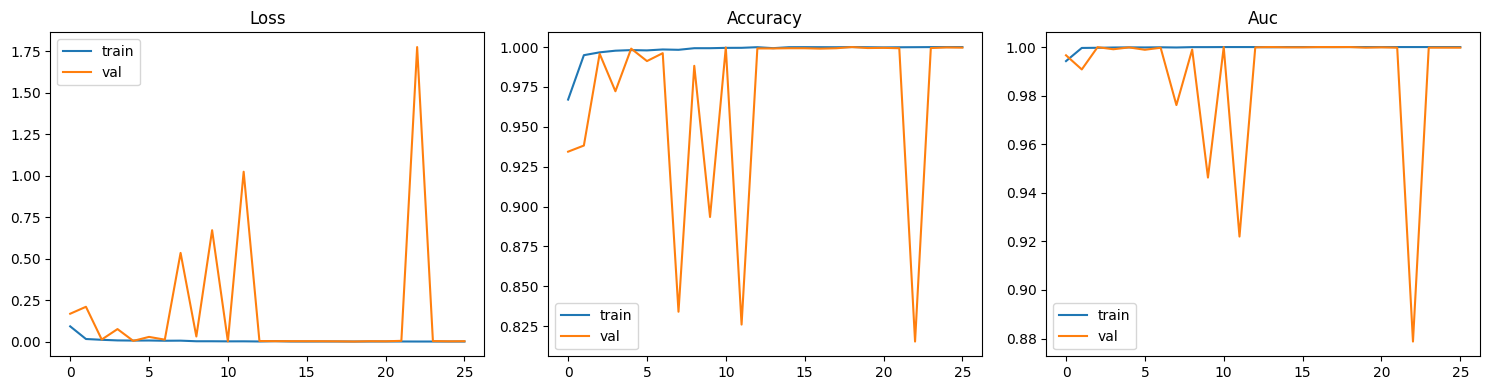

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['loss', 'accuracy', 'auc']):
    ax.plot(history.history[metric], label='train')
    ax.plot(history.history[f'val_{metric}'], label='val')
    ax.set_title(metric.capitalize())
    ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Load best model weights
model.load_weights("/kaggle/working/best_model.keras")

y_pred_proba = model.predict(X_test_cnn).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

# --- Overall Accuracy ---
acc = accuracy_score(y_test, y_pred)

# --- F1 Score ---
f1 = f1_score(y_test, y_pred)

# --- Confusion Matrix & Per-Class Accuracy ---
cm = confusion_matrix(y_test, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# --- Equal Error Rate (EER) ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
fnr = 1 - tpr
eer_threshold_idx = np.nanargmin(np.abs(fnr - fpr))
eer = (fpr[eer_threshold_idx] + fnr[eer_threshold_idx]) / 2

print("===== TEST SET RESULTS =====")
print(f"Overall Accuracy : {acc*100:.2f}%  (target >= 80%)")
print(f"F1 Score         : {f1*100:.2f}%  (target >= 80%)")
print(f"Equal Error Rate : {eer*100:.2f}%  (target <= 12%)")
print(f"Per-Class Acc    : Genuine={per_class_acc[0]*100:.2f}%, "
      f"Deepfake={per_class_acc[1]*100:.2f}%  (target >= 75% each)")
print()
print(classification_report(y_test, y_pred, target_names=["Genuine", "Deepfake"]))

253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
===== TEST SET RESULTS =====
Overall Accuracy : 99.98%  (target >= 80%)
F1 Score         : 99.98%  (target >= 80%)
Equal Error Rate : 0.01%  (target <= 12%)
Per-Class Acc    : Genuine=99.98%, Deepfake=99.98%  (target >= 75% each)

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00      4042
    Deepfake       1.00      1.00      1.00      4039

    accuracy                           1.00      8081
   macro avg       1.00      1.00      1.00      8081
weighted avg       1.00      1.00      1.00      8081



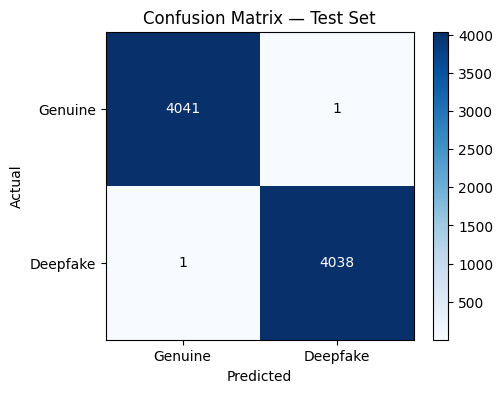

In [19]:
# Confusion matrix heatmap
labels = ["Genuine", "Deepfake"]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.colorbar(im)
plt.show()

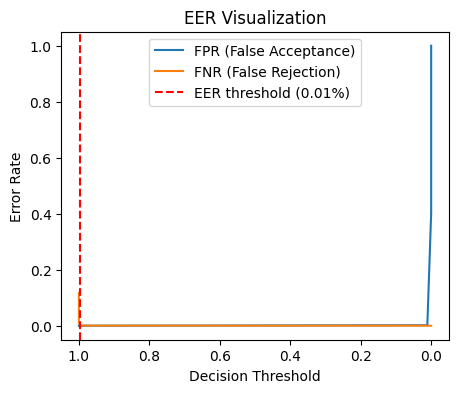

In [20]:
# DET-style curve to visualize EER
plt.figure(figsize=(5, 4))
plt.plot(thresholds, fpr, label="FPR (False Acceptance)")
plt.plot(thresholds, fnr, label="FNR (False Rejection)")
plt.axvline(thresholds[eer_threshold_idx], color='red', linestyle='--',
            label=f"EER threshold ({eer*100:.2f}%)")
plt.xlabel("Decision Threshold")
plt.ylabel("Error Rate")
plt.title("EER Visualization")
plt.legend()
plt.gca().invert_xaxis()
plt.show()


In [22]:
model.save("deepfake_audio_cnn.keras")

report = {
    "overall_accuracy": float(acc),
    "f1_score": float(f1),
    "eer": float(eer),
    "per_class_accuracy": {
        "Genuine": float(per_class_acc[0]),
        "Deepfake": float(per_class_acc[1])
    },
    "confusion_matrix": cm.tolist(),
    "config": {
        "sample_rate": SR,
        "duration_sec": DURATION,
        "n_mels": N_MELS,
        "n_fft": N_FFT,
        "hop_length": HOP_LENGTH,
        "normalization_mean": float(mean),
        "normalization_std": float(std)
    }
}

import json
with open("performance_report.json", "w") as f:
    json.dump(report, f, indent=2)

print(json.dumps(report, indent=2))

{
  "overall_accuracy": 0.9997525058779854,
  "f1_score": 0.9997524139638524,
  "eer": 0.00012379301807380338,
  "per_class_accuracy": {
    "Genuine": 0.999752597723899,
    "Deepfake": 0.9997524139638524
  },
  "confusion_matrix": [
    [
      4041,
      1
    ],
    [
      1,
      4038
    ]
  ],
  "config": {
    "sample_rate": 16000,
    "duration_sec": 4,
    "n_mels": 128,
    "n_fft": 1024,
    "hop_length": 512,
    "normalization_mean": -61.501808166503906,
    "normalization_std": 19.617700576782227
  }
}


In [24]:
def predict_audio(filepath, model, mean, std, sr=SR, duration=DURATION):
    """Returns (label_str, confidence) for a given audio file."""
    y = load_audio(filepath, sr=sr, duration=duration)
    log_mel = audio_to_logmel(y)
    log_mel_norm = (log_mel - mean) / (std + 1e-9)
    x = log_mel_norm[np.newaxis, ..., np.newaxis]

    prob = float(model.predict(x, verbose=0).ravel()[0])
    label = "Deepfake (AI-Generated)" if prob >= 0.5 else "Genuine (Human)"
    confidence = prob if prob >= 0.5 else 1 - prob
    return label, confidence

# Quick demo on a couple of test-set files
for idx in [0, 1]:
    sample_path = df.iloc[idx]['filepath']
    label, conf = predict_audio(sample_path, model, mean, std)
    true_label = "Genuine" if df.iloc[idx]['label'] == 0 else "Deepfake"
    print(f"File: {os.path.basename(sample_path)}")
    print(f"  True label : {true_label}")
    print(f"  Prediction : {label}  (confidence: {conf*100:.2f}%)\n")

File: file4916.wav_16k.wav_norm.wav_mono.wav_silence.wav
  True label : Genuine
  Prediction : Genuine (Human)  (confidence: 100.00%)

File: file21920.wav_16k.wav_norm.wav_mono.wav_silence.wav
  True label : Genuine
  Prediction : Genuine (Human)  (confidence: 100.00%)

